# GVH Diagonal Cubic — RACC-C.4-real.2.7
## GW150914 H1/L1 — Local Time-Frequency Transfer Regime Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.7`  
**Noyau GVH Diagonal modifié : NON**

Objectif :

\[
(t,f)\rightarrow
\{\text{stable},\text{transition},\text{non-stable},\text{non-résolu/faible SNR}\}
\]

pour le transfert empirique \(T_{H1\rightarrow L1}(f,t)\).

Ce notebook teste où le transfert est stable, où il change de régime, si l'instabilité augmente lorsque le chirp monte en fréquence, et s'il existe des domaines locaux reproductibles.

Stop-rule :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

Chaîne HH et `DISPERSION_READY` inchangées.


In [ ]:

import os,sys,subprocess,importlib,json
from pathlib import Path
def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
try: import lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches(); import lalframe
try: import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import median_abs_deviation, pearsonr, spearmanr
from gwpy.timeseries import TimeSeries
print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [ ]:

GPS_EVENT=1126259462.0; FS_EXPECTED=4096.0
def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists(): hits+=list(d.glob(pattern))
    return hits[0].resolve() if hits else None
H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception: pass
if H1 is None or L1 is None: raise FileNotFoundError("H1/L1 introuvables.")
h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")
h1=np.asarray(h1_ts.value,float); l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value); gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT
assert np.isclose(fs,FS_EXPECTED) and len(h1)==len(l1)
print(H1.name); print(L1.name); print(len(h1),fs)


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
131072 4096.0


## 2 — Prétraitement commun

In [ ]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))
def center(x): return np.asarray(x,float)-np.mean(x)
def whiten(x):
    x=center(x); n=len(x); f=np.fft.rfftfreq(n,1/fs); X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1]); floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])
def band_notch(x,lo=35,hi=350):
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        if lo<f0<hi:
            b,a=signal.iirnotch(f0,Q=30,fs=fs); y=signal.filtfilt(b,a,y)
    return y
H=band_notch(whiten(h1)); L=band_notch(whiten(l1))
EVENT=(-.16,.08); em=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])
He=H[em]; Le=L[em]
print("event samples:",len(He))


event samples: 983


## 3 — STFT et transfert local

In [ ]:

NPER=256; NOVER=224
f,t,Zh=signal.stft(He,fs=fs,nperseg=NPER,noverlap=NOVER,window="hann",boundary=None)
_,_,Zl=signal.stft(Le,fs=fs,nperseg=NPER,noverlap=NOVER,window="hann",boundary=None)
t_global=t+EVENT[0]
eps=np.finfo(float).eps
Tlocal=(Zl*np.conj(Zh))/(np.abs(Zh)**2+eps)
power=np.abs(Zh)*np.abs(Zl)
band=(f>=40)&(f<=300)
print("STFT shape:",Zh.shape)


STFT shape: (129, 24)


## 4 — Classification locale

In [ ]:

P=power[band,:]
P70=np.quantile(P,0.70); P40=np.quantile(P,0.40)

# grids indexed by valid frequency and time
valid_f=np.where(band)[0]
rows=[]
for jj,tj in enumerate(t_global):
    for ii in valid_f:
        rows.append({
            "t":float(tj),"f":float(f[ii]),
            "amp":float(np.abs(Tlocal[ii,jj])),
            "phase":float(np.angle(Tlocal[ii,jj])),
            "power":float(power[ii,jj]),
            "snr_class":"low" if power[ii,jj]<P40 else ("medium" if power[ii,jj]<P70 else "high")
        })
tiles=pd.DataFrame(rows)

times=np.sort(tiles.t.unique()); freqs=np.sort(tiles.f.unique())
grid=tiles.set_index(["t","f"])
local=[]

for ti,tv in enumerate(times):
    for fi,fv in enumerate(freqs):
        if (tv,fv) not in grid.index: continue
        t_neigh=times[max(0,ti-1):min(len(times),ti+2)]
        f_neigh=freqs[max(0,fi-1):min(len(freqs),fi+2)]
        vals=[]
        for tn in t_neigh:
            for fn in f_neigh:
                if (tn,fn) in grid.index:
                    r=grid.loc[(tn,fn)]
                    vals.append((r.amp,r.phase,r.power))
        if len(vals)<4: continue
        amp=np.array([v[0] for v in vals]); ph=np.unwrap(np.array([v[1] for v in vals])); pw=np.array([v[2] for v in vals])
        amp_med=np.median(amp)
        amp_cv=np.median(np.abs(amp-amp_med))/(abs(amp_med)+1e-12)
        ph_med=np.median(ph)
        phase_mad=np.median(np.abs(ph-ph_med))
        z=amp*np.exp(1j*ph); z0=np.average(z,weights=pw)
        complex_dist=np.median(np.abs(z-z0))/(np.median(np.abs(z))+1e-12)
        center_row=grid.loc[(tv,fv)]
        local.append({
            "t":tv,"f":fv,
            "amp_cv_local":float(amp_cv),
            "phase_mad_local":float(phase_mad),
            "complex_dist_local":float(complex_dist),
            "power":float(center_row.power),
            "snr_class":center_row.snr_class
        })

local_df=pd.DataFrame(local)

def classify(r):
    if r.snr_class=="low": return "UNRESOLVED_LOW_SNR"
    if r.amp_cv_local<0.20 and r.phase_mad_local<0.40 and r.complex_dist_local<0.20: return "STABLE"
    if r.amp_cv_local>0.40 or r.phase_mad_local>1.00 or r.complex_dist_local>0.40: return "NONSTABLE"
    return "TRANSITION"

local_df["regime"]=local_df.apply(classify,axis=1)
display(local_df.regime.value_counts().to_frame("count"))


,count
regime,
NONSTABLE,203
UNRESOLVED_LOW_SNR,154
TRANSITION,24
STABLE,3


## 5 — Carte temps-fréquence

/tmp/ipykernel_485/2241703476.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  code=pivot.replace(codes).astype(float)


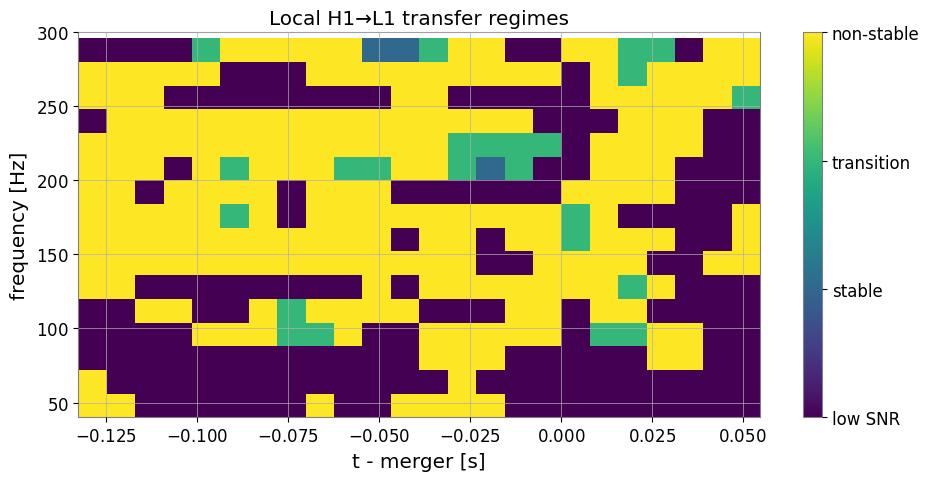

In [ ]:

codes={"UNRESOLVED_LOW_SNR":0,"STABLE":1,"TRANSITION":2,"NONSTABLE":3}
pivot=local_df.pivot(index="f",columns="t",values="regime")
code=pivot.replace(codes).astype(float)
plt.figure(figsize=(11,5))
plt.pcolormesh(code.columns,code.index,code.values,shading="auto")
plt.xlabel("t - merger [s]"); plt.ylabel("frequency [Hz]")
plt.title("Local H1→L1 transfer regimes")
cb=plt.colorbar(); cb.set_ticks([0,1,2,3]); cb.set_ticklabels(["low SNR","stable","transition","non-stable"])
plt.ylim(40,300); plt.show()


## 6 — Régimes par bande et évolution avec la fréquence

In [ ]:

FREQ_BINS=[("40-100",40,100),("100-180",100,180),("180-240",180,240),("240-300",240,300)]
band_rows=[]
for name,lo,hi in FREQ_BINS:
    d=local_df[(local_df.f>=lo)&(local_df.f<hi)]
    n=len(d); c=d.regime.value_counts()
    band_rows.append({
        "band":name,"n":n,
        "stable_fraction":c.get("STABLE",0)/n if n else np.nan,
        "transition_fraction":c.get("TRANSITION",0)/n if n else np.nan,
        "nonstable_fraction":c.get("NONSTABLE",0)/n if n else np.nan,
        "unresolved_fraction":c.get("UNRESOLVED_LOW_SNR",0)/n if n else np.nan
    })
band_regime_df=pd.DataFrame(band_rows); display(band_regime_df)

time_rows=[]
for tv,d in local_df.groupby("t"):
    resolved=d[d.regime!="UNRESOLVED_LOW_SNR"]
    if len(resolved)==0: continue
    fcent=np.average(d.f.to_numpy(float),weights=d.power.to_numpy(float))
    c=resolved.regime.value_counts(); nr=len(resolved)
    time_rows.append({
        "t":tv,
        "power_weighted_frequency":float(fcent),
        "stable_fraction":c.get("STABLE",0)/nr,
        "transition_fraction":c.get("TRANSITION",0)/nr,
        "nonstable_fraction":c.get("NONSTABLE",0)/nr
    })
time_regime_df=pd.DataFrame(time_rows); display(time_regime_df.head())

if len(time_regime_df)>=5:
    pear_r,pear_p=pearsonr(time_regime_df.power_weighted_frequency,time_regime_df.nonstable_fraction)
    spear_r,spear_p=spearmanr(time_regime_df.power_weighted_frequency,time_regime_df.nonstable_fraction)
else:
    pear_r=pear_p=spear_r=spear_p=np.nan

print("Pearson:",pear_r,pear_p)
print("Spearman:",spear_r,spear_p)


,band,n,stable_fraction,transition_fraction,nonstable_fraction,unresolved_fraction
0,40-100,96,0.000000,0.041667,0.260417,0.697917
1,100-180,120,0.000000,0.041667,0.650000,0.308333
2,180-240,72,0.013889,0.125000,0.583333,0.277778
3,240-300,96,0.020833,0.062500,0.604167,0.312500


,t,power_weighted_frequency,stable_fraction,transition_fraction,nonstable_fraction
0,-0.128750,179.386206,0.0,0.0,1.0
1,-0.120938,184.463533,0.0,0.0,1.0
2,-0.113125,193.505614,0.0,0.0,1.0
3,-0.105313,186.724565,0.0,0.0,1.0
4,-0.097500,191.297972,0.0,0.1,0.9


Pearson: 0.35504033302043214 0.08866930307209339
Spearman: 0.3058218461341622 0.14613452691126014


## 7 — Reproductibilité des domaines stables

In [ ]:

stable=local_df[local_df.regime=="STABLE"].copy()
stable["f_bin"]=pd.cut(stable.f,bins=[40,80,120,160,200,240,300],right=False)
nominal_dt=np.median(np.diff(np.sort(local_df.t.unique()))) if local_df.t.nunique()>1 else np.nan

repro=[]
for fbin,d in stable.groupby("f_bin",observed=True):
    ts=np.sort(d.t.unique())
    reproducible=bool(len(ts)>=2 and np.any(np.diff(ts)<=1.5*nominal_dt)) if np.isfinite(nominal_dt) else False
    repro.append({
        "f_bin":str(fbin),
        "n_stable_tiles":len(d),
        "n_times":len(ts),
        "reproducible_adjacent_time":reproducible
    })
repro_df=pd.DataFrame(repro); display(repro_df)
N_REPRODUCIBLE=int(repro_df.reproducible_adjacent_time.sum()) if len(repro_df) else 0
print("N reproducible stable bands =",N_REPRODUCIBLE)


,f_bin,n_stable_tiles,n_times,reproducible_adjacent_time
0,"[200, 240)",1,1,False
1,"[240, 300)",2,2,True


N reproducible stable bands = 1


## 8 — Verdict

In [ ]:

resolved=local_df[local_df.regime!="UNRESOLVED_LOW_SNR"]
resolved_fraction=len(resolved)/len(local_df) if len(local_df) else 0
stable_fraction=(resolved.regime=="STABLE").mean() if len(resolved) else 0
nonstable_fraction=(resolved.regime=="NONSTABLE").mean() if len(resolved) else 0

LOCAL_STABLE_DOMAINS_EXIST=bool(stable_fraction>=0.10 and N_REPRODUCIBLE>=1)
GLOBAL_NONSTATIONARITY_CONFIRMED=bool(nonstable_fraction>=0.20)
HIGHER_FREQ_INSTABILITY_HINT=bool(np.isfinite(spear_r) and spear_r>0.30)

if len(local_df)<50 or resolved_fraction<0.30:
    FINAL_STATUS="UNRESOLVED"
elif LOCAL_STABLE_DOMAINS_EXIST and GLOBAL_NONSTATIONARITY_CONFIRMED:
    FINAL_STATUS="LOCAL-STABLE-REGIMES-WITH-GLOBAL-NONSTATIONARITY"
elif GLOBAL_NONSTATIONARITY_CONFIRMED:
    FINAL_STATUS="DOMINANTLY-NONSTATIONARY"
elif LOCAL_STABLE_DOMAINS_EXIST:
    FINAL_STATUS="LOCALLY-STABLE"
else:
    FINAL_STATUS="NO-ROBUST-REGIME-CLASSIFICATION"

artifact={
    "step":"RACC-C.4-real.2.7",
    "event":"GW150914",
    "resolved_fraction":float(resolved_fraction),
    "stable_fraction_resolved":float(stable_fraction),
    "nonstable_fraction_resolved":float(nonstable_fraction),
    "N_reproducible_stable_bands":N_REPRODUCIBLE,
    "spearman_frequency_vs_nonstable":None if not np.isfinite(spear_r) else float(spear_r),
    "spearman_p":None if not np.isfinite(spear_p) else float(spear_p),
    "LOCAL_STABLE_DOMAINS_EXIST":LOCAL_STABLE_DOMAINS_EXIST,
    "GLOBAL_NONSTATIONARITY_CONFIRMED":GLOBAL_NONSTATIONARITY_CONFIRMED,
    "HIGHER_FREQ_INSTABILITY_HINT":HIGHER_FREQ_INSTABILITY_HINT,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}
print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.7",
  "event": "GW150914",
  "resolved_fraction": 0.5989583333333334,
  "stable_fraction_resolved": 0.013043478260869565,
  "nonstable_fraction_resolved": 0.8826086956521739,
  "N_reproducible_stable_bands": 1,
  "spearman_frequency_vs_nonstable": 0.3058218461341622,
  "spearman_p": 0.14613452691126014,
  "LOCAL_STABLE_DOMAINS_EXIST": false,
  "GLOBAL_NONSTATIONARITY_CONFIRMED": true,
  "HIGHER_FREQ_INSTABILITY_HINT": true,
  "final_status": "DOMINANTLY-NONSTATIONARY",
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "core_GVH_modified": false
}


## 9 — Stop-rule finale

Si `LOCAL-STABLE-REGIMES-WITH-GLOBAL-NONSTATIONARITY` est obtenu, une étape suivante pourra tester un transfert local \(T(f,t)\) uniquement dans les domaines stables, avec validation hors-échantillon adaptée.

Cela ne certifie toujours pas le timing H1/L1.
